##  Data & Setup (10 points)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

## The Failure of Linear Regression (15 points)

In [2]:
# Load dataset
data = load_breast_cancer()

# Create a Pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column (optional but useful)
df['target'] = data.target

# Display shape
print("Number of samples (rows):", df.shape[0])
print("Number of features (columns, excluding target):", df.shape[1] - 1)

# Split the data into Training (80%) and Test (20%) sets
X = df.drop('target', axis=1)
y = df['target']

# Select one feature
X = df[['mean radius']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Number of samples (rows): 569
Number of features (columns, excluding target): 30
Training set shape: (455, 1)
Test set shape: (114, 1)


In [3]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

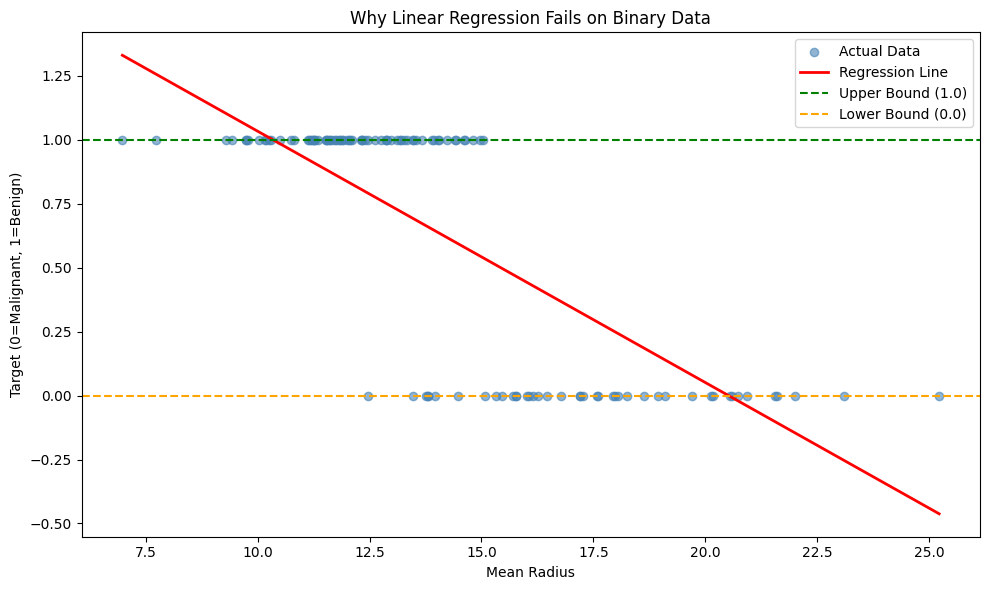

In [4]:
# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, label='Actual Data')
plt.plot(sorted(X_test['mean radius']),
         sorted(y_pred, reverse=True),
         color='red', linewidth=2, label='Regression Line')
plt.axhline(y=1.0, color='green', linestyle='--', label='Upper Bound (1.0)')
plt.axhline(y=0.0, color='orange', linestyle='--', label='Lower Bound (0.0)')
plt.xlabel('Mean Radius')
plt.ylabel('Target (0=Malignant, 1=Benign)')
plt.title('Why Linear Regression Fails on Binary Data')
plt.legend()
plt.tight_layout()
plt.show()

## Logistic Regression Analysis

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import pandas as pd
import numpy as np


# Set plot style for better visuals
sns.set_style('whitegrid')


In [6]:
# Load & Split
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# a. Train Logistic Regression (all features)
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# b. Top 3 most influential features
coefficients = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model.coef_[0]
})
coefficients['Abs_Coef'] = coefficients['Coefficient'].abs()
top3 = coefficients.nlargest(3, 'Abs_Coef')[['Feature', 'Coefficient']]
print("Top 3 Most Influential Features:")
print(top3.to_string(index=False))

# c. Evaluation on Test Set
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nConfusion Matrix:\n{cm}")
print(f"\nAccuracy:  {acc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

Top 3 Most Influential Features:
        Feature  Coefficient
worst concavity    -1.428595
  texture error     1.370567
    mean radius     1.027437

Confusion Matrix:
[[39  4]
 [ 1 70]]

Accuracy:  0.9561
Recall:    0.9859
F1-Score:  0.9655


In [7]:
# a. Threshold Tuning at 0.3
y_prob = model.predict_proba(X_test)[:, 1]  # get probabilities

# Apply 0.3 threshold
y_pred_03 = (y_prob >= 0.3).astype(int)
y_pred_05 = (y_prob >= 0.5).astype(int)  # default

recall_05 = recall_score(y_test, y_pred_05)
recall_03 = recall_score(y_test, y_pred_03)
f1_05 = f1_score(y_test, y_pred_05)
f1_03 = f1_score(y_test, y_pred_03)

print("Default Threshold (0.5):")
print(f"  Recall: {recall_05:.4f} | F1: {f1_05:.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred_05)}\n")

print("Lower Threshold (0.3):")
print(f"  Recall: {recall_03:.4f} | F1: {f1_03:.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred_03)}")

Default Threshold (0.5):
  Recall: 0.9859 | F1: 0.9655
  Confusion Matrix:
[[39  4]
 [ 1 70]]

Lower Threshold (0.3):
  Recall: 0.9859 | F1: 0.9655
  Confusion Matrix:
[[39  4]
 [ 1 70]]
